In [1]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from models.autoencoder import ConvolutionalAutoencoder, DenoisingAutoencoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
data_dir = '../dataSet/archive/seg_train/seg_train'
test_dir = '../dataSet/archive/seg_test/seg_test'

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

full_train = datasets.ImageFolder(data_dir, transform=transform)
train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size
train_dataset, val_dataset = random_split(full_train, [train_size, val_size])
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

class_names = full_train.classes
print(f'Classes: {class_names}')
print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}')

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train: 11227, Val: 2807, Test: 3000


In [3]:
def train_autoencoder(model, train_loader, val_loader, num_epochs=30, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        'train_loss': [],
        'val_loss': []
    }

    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        for images, _ in train_loader:
            images = images.to(device)

            optimizer.zero_grad()
            reconstructed, _ = model(images)
            loss = criterion(reconstructed, images)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

        train_loss = train_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, _ in val_loader:
                images = images.to(device)
                reconstructed, _ = model(images)
                loss = criterion(reconstructed, images)
                val_loss += loss.item() * images.size(0)

        val_loss = val_loss / len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            Path('../checkpoints').mkdir(exist_ok=True)
            torch.save(model.state_dict(), '../checkpoints/autoencoder_best.pth')
            print(f'  ✓ Saved best model')

    return history

In [4]:
print('Training Autoencoder for latent space visualization...\n')

autoencoder = ConvolutionalAutoencoder(latent_dim=128).to(device)
history = train_autoencoder(autoencoder, train_loader, val_loader, num_epochs=30, lr=1e-3)

print('\nTraining completed!')

Training Autoencoder for latent space visualization...

Epoch [1/30] Train Loss: 0.032301, Val Loss: 0.023546
  ✓ Saved best model
Epoch [2/30] Train Loss: 0.020415, Val Loss: 0.018522
  ✓ Saved best model
Epoch [3/30] Train Loss: 0.017210, Val Loss: 0.016037
  ✓ Saved best model
Epoch [4/30] Train Loss: 0.015908, Val Loss: 0.015001
  ✓ Saved best model
Epoch [5/30] Train Loss: 0.015107, Val Loss: 0.014615
  ✓ Saved best model
Epoch [6/30] Train Loss: 0.014532, Val Loss: 0.013960
  ✓ Saved best model
Epoch [7/30] Train Loss: 0.014092, Val Loss: 0.014703
Epoch [8/30] Train Loss: 0.013937, Val Loss: 0.013508
  ✓ Saved best model
Epoch [9/30] Train Loss: 0.013731, Val Loss: 0.013709
Epoch [10/30] Train Loss: 0.013564, Val Loss: 0.013415
  ✓ Saved best model
Epoch [11/30] Train Loss: 0.013567, Val Loss: 0.013556
Epoch [12/30] Train Loss: 0.013329, Val Loss: 0.013335
  ✓ Saved best model
Epoch [13/30] Train Loss: 0.013238, Val Loss: 0.013422
Epoch [14/30] Train Loss: 0.013179, Val Loss: 0.0

C:\Users\zhenu\AppData\Local\Temp\ipykernel_22332\614791949.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  autoencoder.load_state_dict(torch.load('../checkpoints/autoen

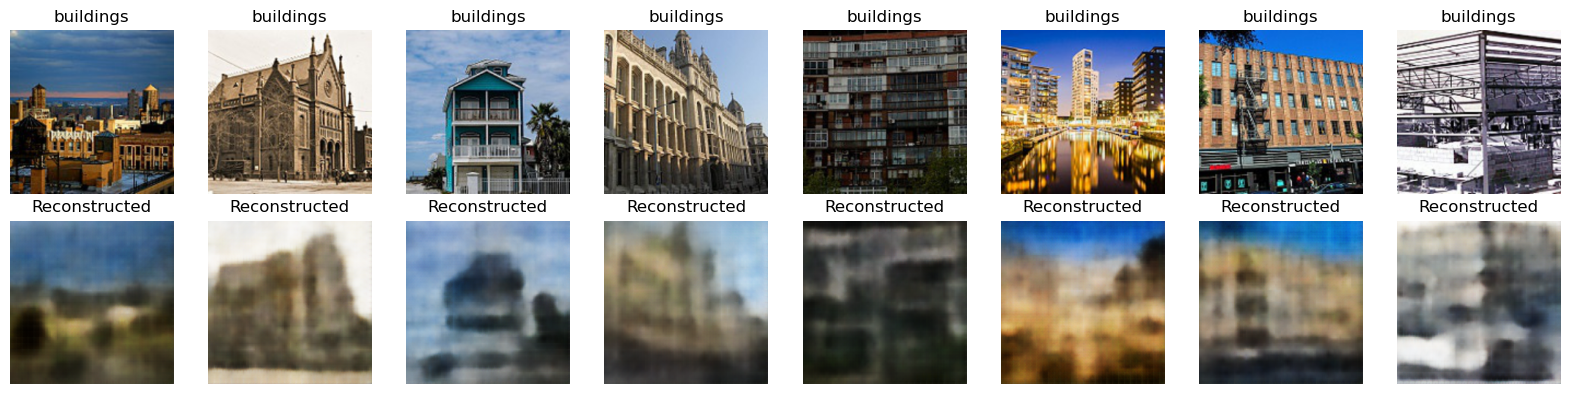

In [10]:
autoencoder.load_state_dict(torch.load('../checkpoints/autoencoder_best.pth'))
autoencoder.eval()

images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    reconstructed, _ = autoencoder(images)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for i in range(8):
    axes[0, i].imshow(images[i+10].cpu().permute(1, 2, 0))
    axes[0, i].set_title(f'{class_names[labels[i]]}')
    axes[0, i].axis('off')

    axes[1, i].imshow(reconstructed[i+10].cpu().permute(1, 2, 0))
    axes[1, i].set_title('Reconstructed')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=12)
axes[1, 0].set_ylabel('Reconstructed', fontsize=12)

plt.tight_layout()
plt.savefig('../results/autoencoder_reconstruction.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
def extract_latent_vectors(model, loader, device):
    model.eval()
    latent_vectors = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            latent = model.encode(images)
            latent_vectors.append(latent.cpu().numpy())
            labels_list.append(labels.numpy())

    latent_vectors = np.concatenate(latent_vectors, axis=0)
    labels_list = np.concatenate(labels_list, axis=0)

    return latent_vectors, labels_list

latent_vectors, labels_array = extract_latent_vectors(autoencoder, test_loader, device)

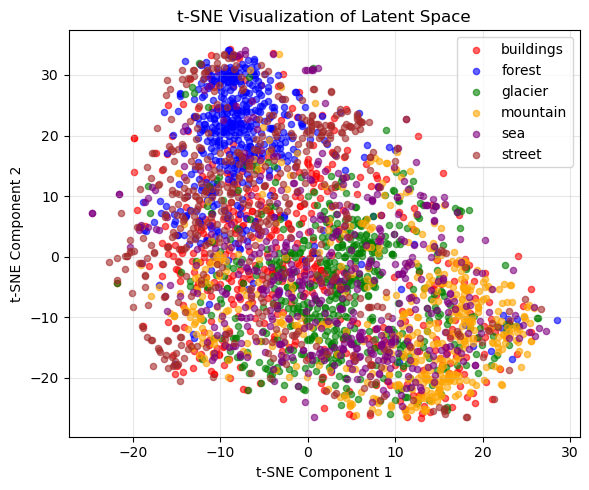

t-SNE completed!


In [22]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
embedded = tsne.fit_transform(latent_vectors)

fig, ax = plt.subplots(figsize=(6, 5))

colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
for i, class_name in enumerate(class_names):
    mask = labels_array == i
    ax.scatter(embedded[mask, 0], embedded[mask, 1],
              c=colors[i], label=class_name, alpha=0.6, s=20)

ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_title('t-SNE Visualization of Latent Space')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/latent_space_tsne.png', dpi=300, bbox_inches='tight')
plt.show()

print('t-SNE completed!')

In [5]:
print('\nTraining Denoising Autoencoder...\n')

denoising_ae = DenoisingAutoencoder(latent_dim=128).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(denoising_ae.parameters(), lr=1e-3)

history_denoising = {
    'train_loss': [],
    'val_loss': []
}

num_epochs = 30
noise_factor = 0.3
best_val_loss = float('inf')

for epoch in range(num_epochs):
    denoising_ae.train()
    train_loss = 0.0

    for images, _ in train_loader:
        clean_images = images.to(device)
        noisy_images = denoising_ae.add_noise(clean_images, noise_factor)

        optimizer.zero_grad()
        reconstructed, _ = denoising_ae(noisy_images)
        loss = criterion(reconstructed, clean_images)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss = train_loss / len(train_loader.dataset)

    denoising_ae.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, _ in val_loader:
            clean_images = images.to(device)
            noisy_images = denoising_ae.add_noise(clean_images, noise_factor)
            reconstructed, _ = denoising_ae(noisy_images)
            loss = criterion(reconstructed, clean_images)
            val_loss += loss.item() * images.size(0)

    val_loss = val_loss / len(val_loader.dataset)

    history_denoising['train_loss'].append(train_loss)
    history_denoising['val_loss'].append(val_loss)

    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(denoising_ae.state_dict(), '../checkpoints/denoising_autoencoder_best.pth')
        print(f'  ✓ Saved best model')

print('\nDenoising Autoencoder training completed!')


Training Denoising Autoencoder...

Epoch [1/30] Train Loss: 0.031219, Val Loss: 0.024029
  ✓ Saved best model
Epoch [2/30] Train Loss: 0.019592, Val Loss: 0.018231
  ✓ Saved best model
Epoch [3/30] Train Loss: 0.016851, Val Loss: 0.015697
  ✓ Saved best model
Epoch [4/30] Train Loss: 0.015651, Val Loss: 0.016038
Epoch [5/30] Train Loss: 0.015036, Val Loss: 0.014522
  ✓ Saved best model
Epoch [6/30] Train Loss: 0.014490, Val Loss: 0.014134
  ✓ Saved best model
Epoch [7/30] Train Loss: 0.014122, Val Loss: 0.014035
  ✓ Saved best model
Epoch [8/30] Train Loss: 0.013928, Val Loss: 0.013711
  ✓ Saved best model
Epoch [9/30] Train Loss: 0.013662, Val Loss: 0.013493
  ✓ Saved best model
Epoch [10/30] Train Loss: 0.013545, Val Loss: 0.013478
  ✓ Saved best model
Epoch [11/30] Train Loss: 0.013536, Val Loss: 0.013484
Epoch [12/30] Train Loss: 0.013389, Val Loss: 0.013813
Epoch [13/30] Train Loss: 0.013220, Val Loss: 0.013397
  ✓ Saved best model
Epoch [14/30] Train Loss: 0.013186, Val Loss: 0.

C:\Users\zhenu\AppData\Local\Temp\ipykernel_22332\970953682.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  denoising_ae.load_state_dict(torch.load('../checkpoints/denoi

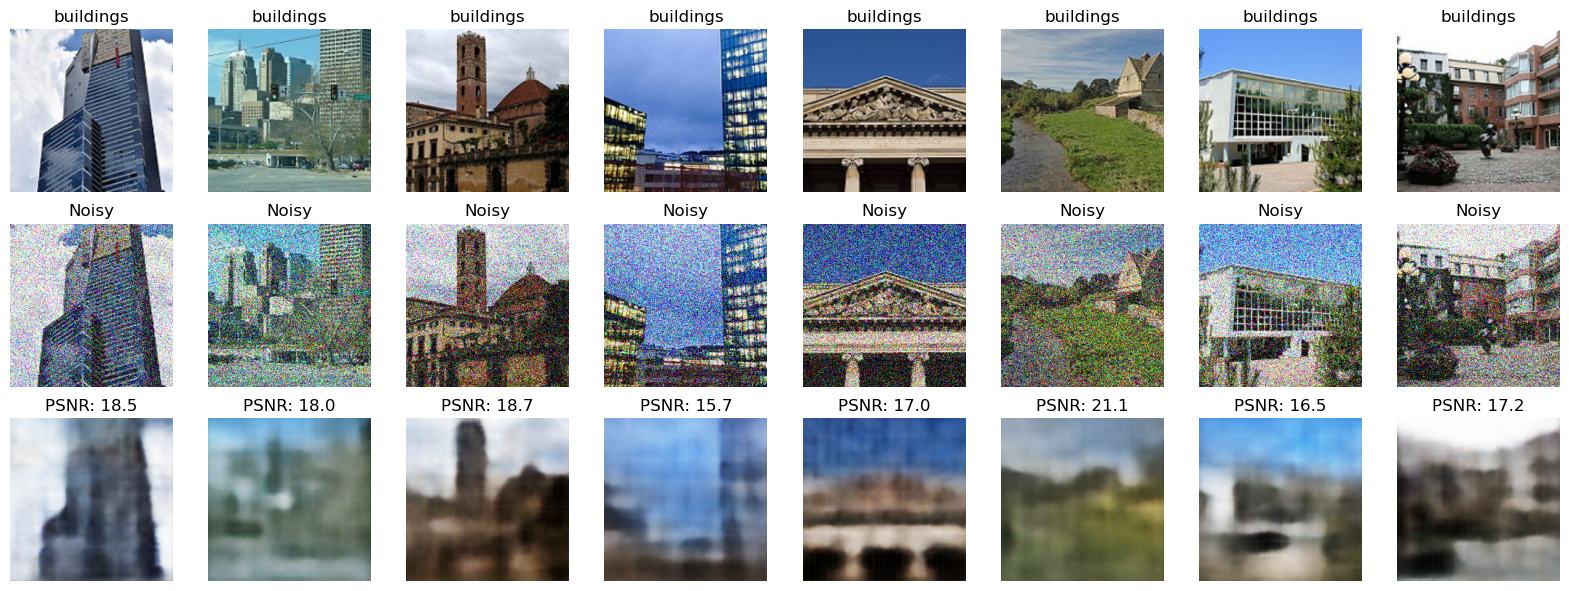

In [15]:
denoising_ae.load_state_dict(torch.load('../checkpoints/denoising_autoencoder_best.pth'))
denoising_ae.eval()

images, labels = next(iter(test_loader))
clean_images = images.to(device)
noisy_images = denoising_ae.add_noise(clean_images, noise_factor=0.3)

with torch.no_grad():
    denoised, _ = denoising_ae(noisy_images)

def calculate_psnr(img1, img2):
    mse = torch.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * torch.log10(1.0 / torch.sqrt(mse))

fig, axes = plt.subplots(3, 8, figsize=(16, 6))

for i in range(8):
    axes[0, i].imshow(clean_images[i].cpu().permute(1, 2, 0))
    axes[0, i].set_title(f'{class_names[labels[i]]}')
    axes[0, i].axis('off')

    axes[1, i].imshow(noisy_images[i].cpu().permute(1, 2, 0))
    axes[1, i].set_title('Noisy')
    axes[1, i].axis('off')

    psnr = calculate_psnr(clean_images[i], denoised[i])
    axes[2, i].imshow(denoised[i].cpu().permute(1, 2, 0))
    axes[2, i].set_title(f'PSNR: {psnr:.1f}')
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('Clean', fontsize=12)
axes[1, 0].set_ylabel('Noisy', fontsize=12)
axes[2, 0].set_ylabel('Denoised', fontsize=12)

plt.tight_layout()
plt.savefig('../results/denoising_results.png', dpi=300, bbox_inches='tight')
plt.show()